In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.1 MB/s eta 0:00:00


In [6]:
import os
import pandas as pd

# Project paths constants
PROJECT_PATH = '/content/drive/MyDrive/License_Plate_Recognition_Project'
DATA_PATH = f'{PROJECT_PATH}/data'
CSV_PATH = f'{DATA_PATH}/Licplatesdetection_train.csv'
TRAIN_IMAGES_PATH = f'{DATA_PATH}/train_images'
TEST_IMAGES_PATH = f'{DATA_PATH}/test_images/test'

print("🔍 Checking your files...\n")

# CSV file
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"✅ CSV file found: {len(df)} rows")
    print(f"   Columns: {list(df.columns)}")
else:
    print("❌ CSV file NOT found!")

# train images folder
if os.path.exists(TRAIN_IMAGES_PATH):
    train_images = os.listdir(TRAIN_IMAGES_PATH)
    print(f"\n✅ Train images folder found: {len(train_images)} images")
else:
    print("\n❌ Train images folder NOT found!")

# test images folder
if os.path.exists(TEST_IMAGES_PATH):
    test_images = os.listdir(TEST_IMAGES_PATH)
    print(f"\n✅ Test images folder found: {len(test_images)} images")
else:
    print("\n❌ Test images folder NOT found!")

print("\n✅ YOLOv8 installed successfully!")

🔍 Checking your files...

✅ CSV file found: 900 rows
   Columns: ['img_id', 'ymin', 'xmin', 'ymax', 'xmax']

✅ Train images folder found: 900 images

✅ Test images folder found: 210 images

✅ YOLOv8 installed successfully!


CSV DATA STRUCTURE:

    img_id  ymin  xmin  ymax  xmax
0    1.jpg   276    94   326   169
1   10.jpg   311   395   344   444
2  100.jpg   406   263   450   434
3  101.jpg   283   363   315   494
4  102.jpg   139    42   280   222

📈 Dataset Statistics:
Total annotations: 900
Unique images: 900

🖼️  VISUALIZING SAMPLE IMAGES WITH ANNOTATIONS

--- Sample 1 ---

📷 Sample Image: 689.jpg
   Image size: 306x547 pixels
   Box coordinates: (97, 274) to (210, 302)


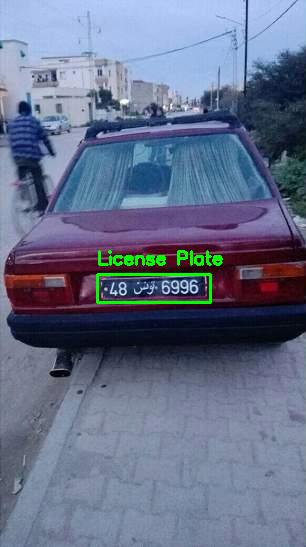


--- Sample 2 ---

📷 Sample Image: 201.jpg
   Image size: 732x547 pixels
   Box coordinates: (257, 368) to (461, 409)


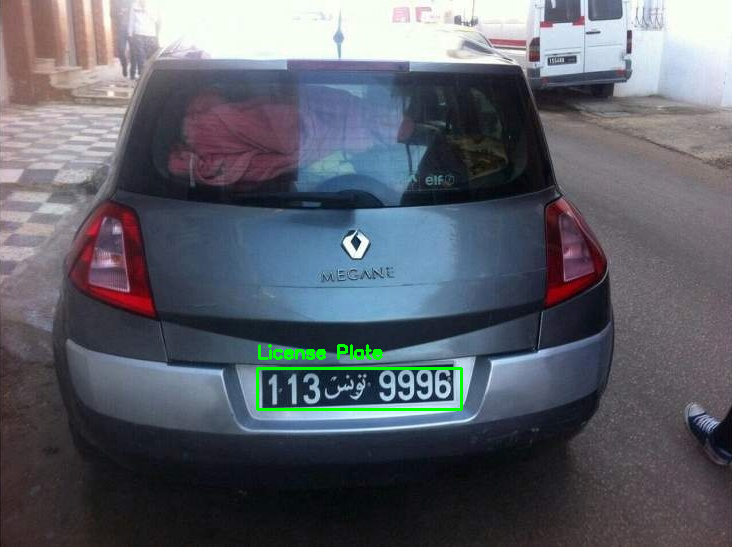


--- Sample 3 ---

📷 Sample Image: 121.jpg
   Image size: 850x477 pixels
   Box coordinates: (333, 403) to (499, 432)


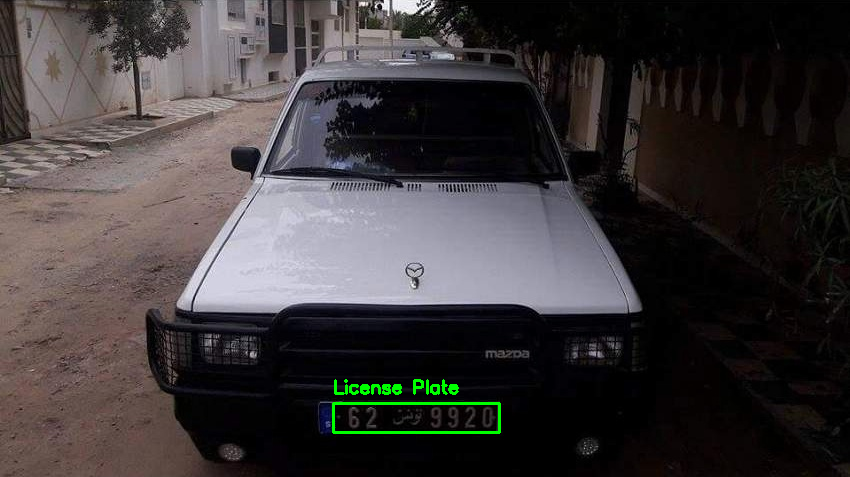

In [5]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Load and explore the CSV
print("CSV DATA STRUCTURE:\n")
print(df.head())  # Show first 5 rows
print(f"\n📈 Dataset Statistics:")
print(f"Total annotations: {len(df)}")
print(f"Unique images: {df['img_id'].nunique()}")


# Function to visualize an image with its bounding box
def visualize_sample(row_number=0):
    """
    Draws a rectangle around the license plate to see the annotation
    """
    # Get annotation data from CSV
    row = df.iloc[row_number]
    img_name = row['img_id']
    xmin, ymin = int(row['xmin']), int(row['ymin'])
    xmax, ymax = int(row['xmax']), int(row['ymax'])

    # Load the image
    img_path = f"{TRAIN_IMAGES_PATH}/{img_name}"
    img = cv2.imread(img_path)

    # Draw green rectangle around license plate
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

    # Add label
    cv2.putText(img, 'License Plate', (xmin, ymin-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Display
    print(f"\n📷 Sample Image: {img_name}")
    print(f"   Image size: {img.shape[1]}x{img.shape[0]} pixels")
    print(f"   Box coordinates: ({xmin}, {ymin}) to ({xmax}, {ymax})")
    cv2_imshow(img)

# Visualize 3 random samples
print("\n" + "="*60)
print("🖼️  VISUALIZING SAMPLE IMAGES WITH ANNOTATIONS")
print("="*60)

import random
random.seed(42)
sample_indices = random.sample(range(len(df)), 3)

for i, idx in enumerate(sample_indices, 1):
    print(f"\n--- Sample {i} ---")
    visualize_sample(idx)

In [7]:
from sklearn.model_selection import train_test_split
import shutil

# Use YOUR project path
YOLO_PATH = f'{PROJECT_PATH}/yolo_dataset'

print("📁 Creating YOLO folder structure...")

# Create folders
folders = [
    f'{YOLO_PATH}/images/train',
    f'{YOLO_PATH}/images/val',
    f'{YOLO_PATH}/labels/train',
    f'{YOLO_PATH}/labels/val'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print(f"✅ Created folders")

# Split data: 80% train, 20% validation
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"📊 Split: {len(train_df)} train, {len(val_df)} val")

# Function to convert coordinates to YOLO format
def convert_to_yolo_format(row, img_width, img_height):
    xmin, ymin = row['xmin'], row['ymin']
    xmax, ymax = row['xmax'], row['ymax']

    x_center = (xmin + xmax) / 2.0
    y_center = (ymin + ymax) / 2.0
    width = xmax - xmin
    height = ymax - ymin

    x_center /= img_width
    y_center /= img_height
    width /= img_width
    height /= img_height

    return x_center, y_center, width, height

# Process training data
print("🔄 Processing training data...")
for idx, row in train_df.iterrows():
    img_name = row['img_id']
    img_path = f"{TRAIN_IMAGES_PATH}/{img_name}"

    img = cv2.imread(img_path)
    img_height, img_width = img.shape[:2]

    x_center, y_center, width, height = convert_to_yolo_format(row, img_width, img_height)

    shutil.copy(img_path, f"{YOLO_PATH}/images/train/{img_name}")

    label_name = os.path.splitext(img_name)[0] + '.txt'
    label_path = f"{YOLO_PATH}/labels/train/{label_name}"

    with open(label_path, 'w') as f:
        f.write(f"0 {x_center} {y_center} {width} {height}")

print(f"✅ Processed {len(train_df)} training images")

# Process validation data
print("🔄 Processing validation data...")
for idx, row in val_df.iterrows():
    img_name = row['img_id']
    img_path = f"{TRAIN_IMAGES_PATH}/{img_name}"

    img = cv2.imread(img_path)
    img_height, img_width = img.shape[:2]

    x_center, y_center, width, height = convert_to_yolo_format(row, img_width, img_height)

    shutil.copy(img_path, f"{YOLO_PATH}/images/val/{img_name}")

    label_name = os.path.splitext(img_name)[0] + '.txt'
    label_path = f"{YOLO_PATH}/labels/val/{label_name}"

    with open(label_path, 'w') as f:
        f.write(f"0 {x_center} {y_center} {width} {height}")

print(f"✅ Processed {len(val_df)} validation images")
print("✅ YOLO dataset ready!")

📁 Creating YOLO folder structure...
✅ Created folders
📊 Split: 720 train, 180 val
🔄 Processing training data...


KeyboardInterrupt: 

In [8]:
# Create dataset.yaml configuration file
YOLO_PATH = f'{PROJECT_PATH}/yolo_dataset'
yaml_content = f"""path: {YOLO_PATH}
train: images/train
val: images/val

nc: 1
names: ['license_plate']
"""

yaml_path = f'{YOLO_PATH}/dataset.yaml'

with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ Dataset configuration created")
print(f"   Training images: 720")
print(f"   Validation images: 180")

✅ Dataset configuration created
   Training images: 720
   Validation images: 180


In [9]:
from ultralytics import YOLO

# Load pretrained YOLOv8 nano model
model = YOLO('yolov8n.pt')

print("🚀 Starting training...")
print(f"   Dataset: {YOLO_PATH}")
print(f"   Training images: 720")
print(f"   Validation images: 180")
print(f"   Using: GPU (T4)\n")

# Train the model
results = model.train(
    data=f'{YOLO_PATH}/dataset.yaml',
    epochs=50,              # Number of training cycles
    imgsz=640,              # Image size
    batch=16,               # Images per batch
    device=0,               # 0 = use GPU
    project=f'{PROJECT_PATH}/models',  # Where to save
    name='license_plate_v1',           # Model name
    patience=10,            # Stop if no improvement for 10 epochs
    save=True,              # Save best model
    plots=True              # Generate training plots
)

print("\n✅ Training complete!")
print(f"   Model saved to: {PROJECT_PATH}/models/license_plate_v1")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Starting training...
   Dataset: /content/drive/MyDrive/License_Plate_Recognition_Project/yolo_dataset
   Training images: 720
   Validation images: 180
   Using: GPU (T4)

Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/License_Plate_Recognition_Project/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0

🎯 Testing your trained model!
   Model: best.pt (Epoch 27, mAP=0.809)
   Test images: 210

🔍 RUNNING DETECTION ON TEST IMAGES

image 1/1 /content/drive/MyDrive/License_Plate_Recognition_Project/data/test_images/test/1048.jpg: 480x640 1 license_plate, 38.2ms
Speed: 2.2ms preprocess, 38.2ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

--- Test Image 1: 1048.jpg ---
   Detection 1: Confidence=0.807 (Box: 275,343 to 429,382)


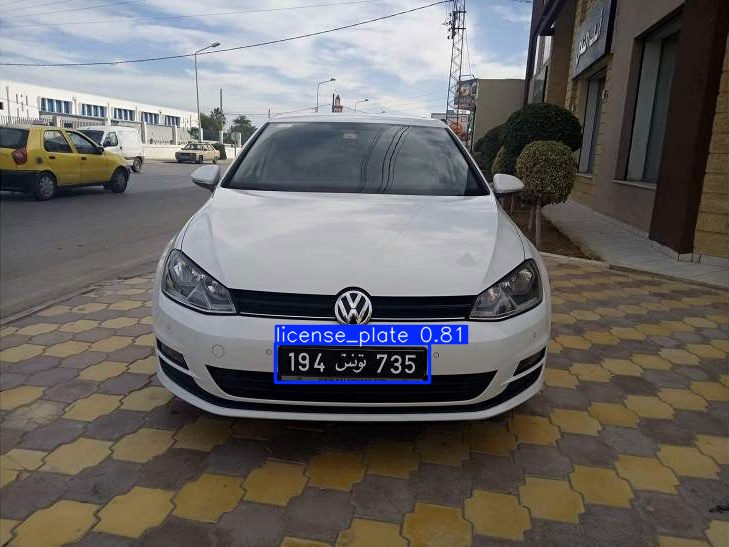


image 1/1 /content/drive/MyDrive/License_Plate_Recognition_Project/data/test_images/test/969.jpg: 640x480 1 license_plate, 38.5ms
Speed: 2.8ms preprocess, 38.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)

--- Test Image 2: 969.jpg ---
   Detection 1: Confidence=0.759 (Box: 32,370 to 204,446)


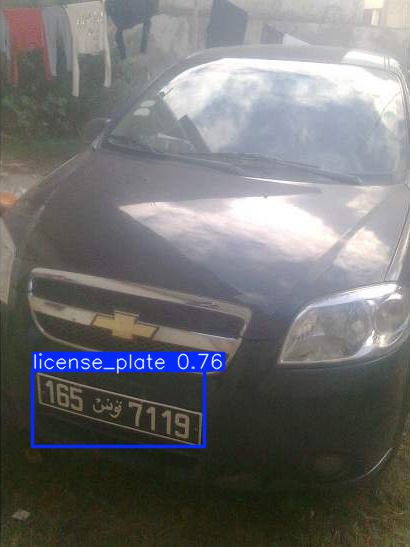


image 1/1 /content/drive/MyDrive/License_Plate_Recognition_Project/data/test_images/test/903.jpg: 640x480 1 license_plate, 113.0ms
Speed: 3.8ms preprocess, 113.0ms inference, 37.9ms postprocess per image at shape (1, 3, 640, 480)

--- Test Image 3: 903.jpg ---
   Detection 1: Confidence=0.822 (Box: 146,353 to 223,374)


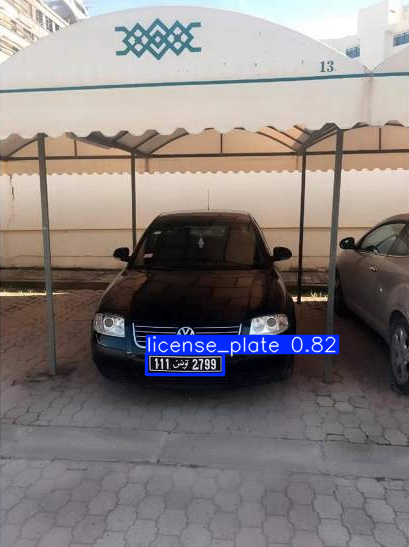


image 1/1 /content/drive/MyDrive/License_Plate_Recognition_Project/data/test_images/test/1077.jpg: 480x640 1 license_plate, 16.0ms
Speed: 4.9ms preprocess, 16.0ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

--- Test Image 4: 1077.jpg ---
   Detection 1: Confidence=0.820 (Box: 134,214 to 284,248)


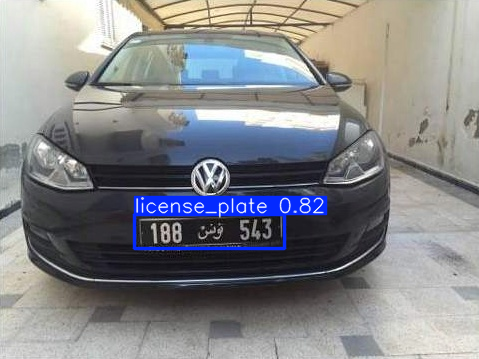


image 1/1 /content/drive/MyDrive/License_Plate_Recognition_Project/data/test_images/test/961.jpg: 640x480 1 license_plate, 47.8ms
Speed: 6.0ms preprocess, 47.8ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 480)

--- Test Image 5: 961.jpg ---
   Detection 1: Confidence=0.842 (Box: 137,257 to 259,288)


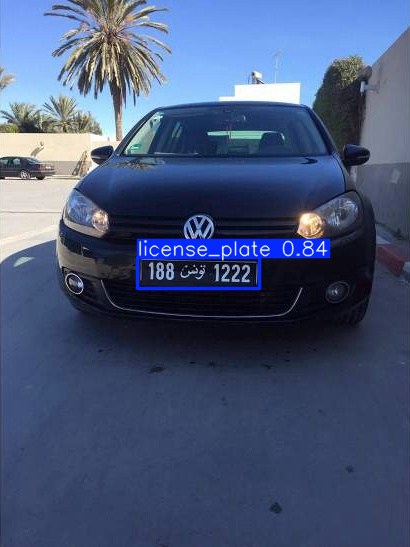


✅ Testing complete!


In [12]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import random

TEST_IMAGES_PATH = f'{DATA_PATH}/test_images/test'


# Load your trained model
model = YOLO(f'{PROJECT_PATH}/models/license_plate_v1/weights/best.pt')

print("🎯 Testing your trained model!")
print(f"   Model: best.pt (Epoch 27, mAP=0.809)")
print(f"   Test images: {len(os.listdir(TEST_IMAGES_PATH))}\n")

# Get random test images
test_image_files = [f for f in os.listdir(TEST_IMAGES_PATH) if f.endswith(('.jpg', '.png', '.jpeg'))]
random.seed(42)
sample_images = random.sample(test_image_files, min(5, len(test_image_files)))

print("="*60)
print("🔍 RUNNING DETECTION ON TEST IMAGES")
print("="*60)

for i, img_name in enumerate(sample_images, 1):
    img_path = f"{TEST_IMAGES_PATH}/{img_name}"

    # Run detection
    results = model(img_path, conf=0.5)

    # Get the annotated image
    annotated_img = results[0].plot()

    # Display results
    print(f"\n--- Test Image {i}: {img_name} ---")

    # Print detection info
    detections = results[0].boxes
    if len(detections) > 0:
        for j, box in enumerate(detections):
            conf = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            print(f"   Detection {j+1}: Confidence={conf:.3f} (Box: {int(x1)},{int(y1)} to {int(x2)},{int(y2)})")
    else:
        print("   No license plates detected")

    # Show image
    cv2_imshow(annotated_img)

print("\n" + "="*60)
print("✅ Testing complete!")

📊 Training Progress:



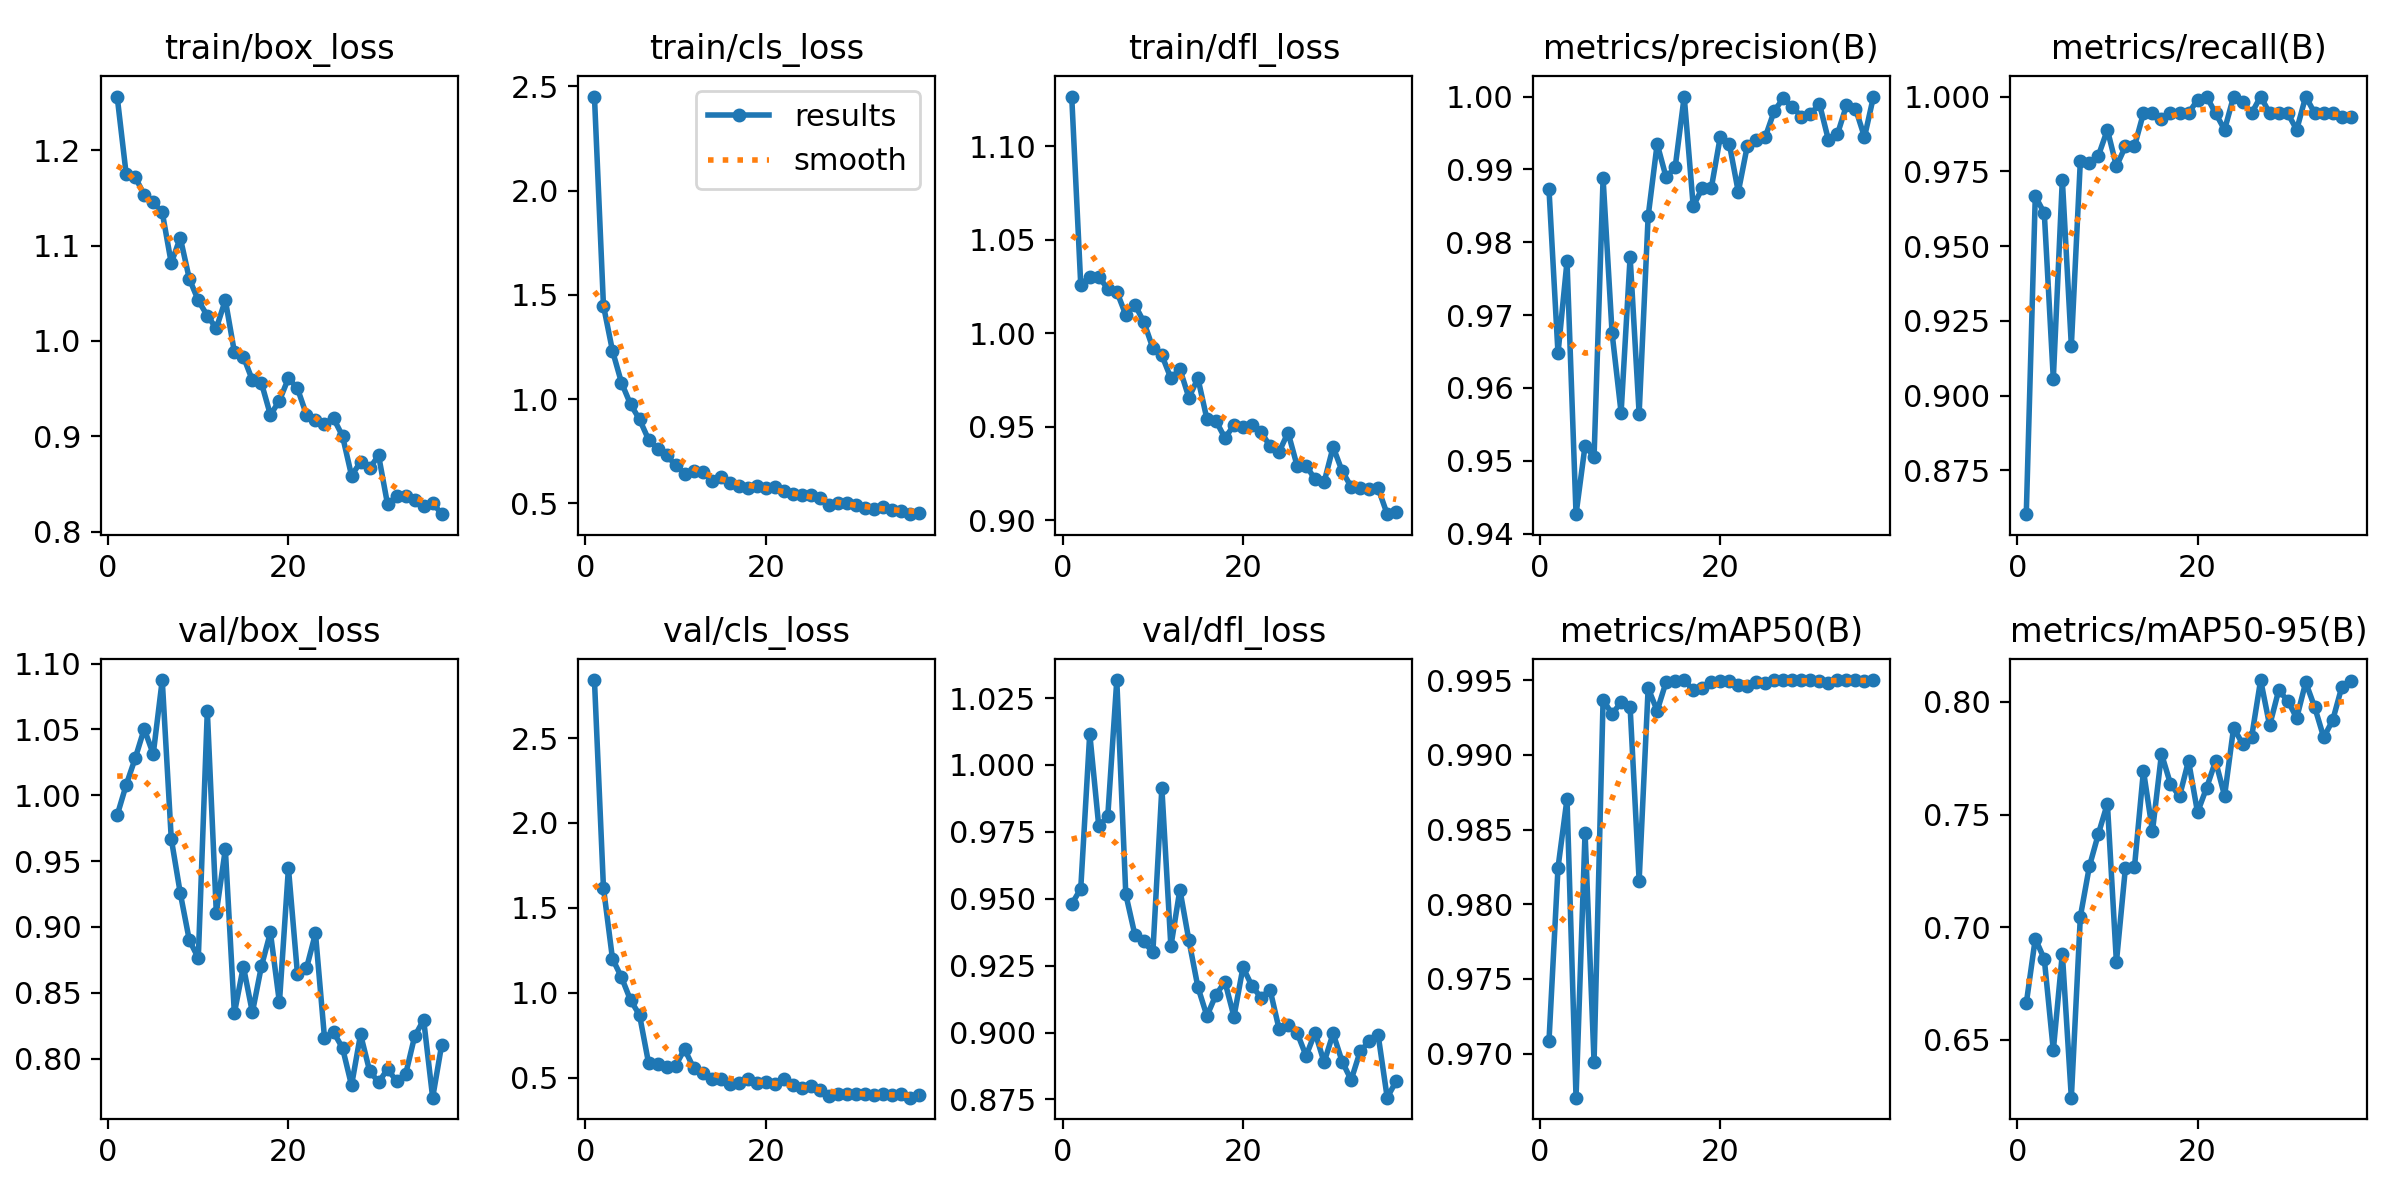

In [14]:
from PIL import Image

# Show training curves
results_img = f'{PROJECT_PATH}/models/license_plate_v1/results.png'

if os.path.exists(results_img):
    print("📊 Training Progress:\n")
    display(Image.open(results_img))
else:
    print("❌ Results image not found")

In [15]:
# Install OCR library
!pip install easyocr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 28.4 MB/s eta 0:00:00


In [1]:
!pip install easyocr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 9.6 MB/s eta 0:00:00


Image 1: 985.jpg | Detection Confidence: 0.808


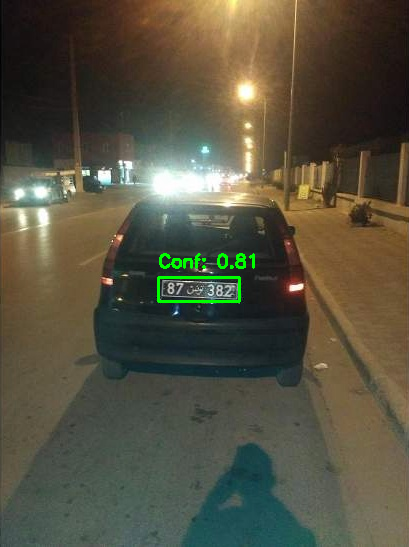


Cropped Plate:


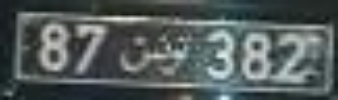


Binary (Otsu):


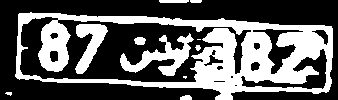


Plate Number: :ش0


Image 2: 939.jpg | Detection Confidence: 0.805


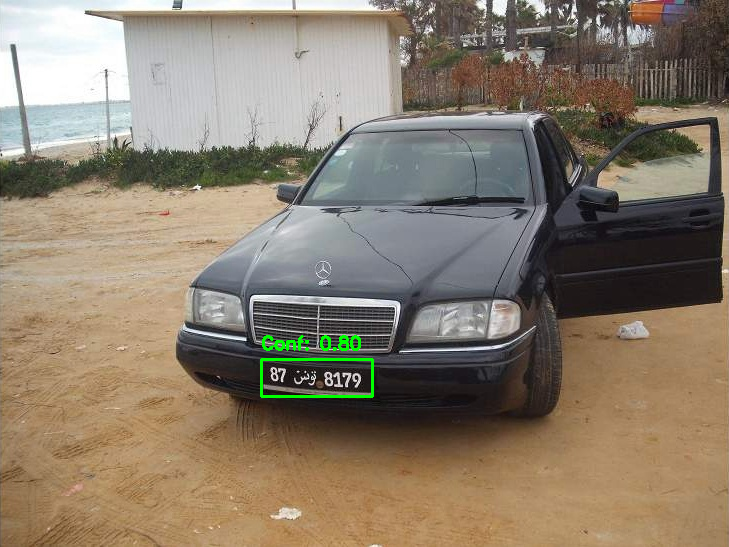


Cropped Plate:


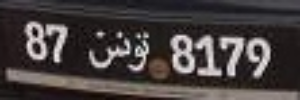


Binary (Otsu):


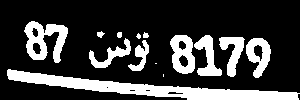


Plate Number: 8179  تونىن 87




In [14]:
import easyocr
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Initializing (silent)
reader = easyocr.Reader(['ar', 'en'], gpu=True, verbose=False)
model = YOLO(f'{PROJECT_PATH}/models/license_plate_v1/weights/best.pt')

# Getting test images
test_image_files = [f for f in os.listdir(TEST_IMAGES_PATH) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
sample_images = test_image_files[23:25]  # 2 examples

for i, img_name in enumerate(sample_images, 1):
    img_path = f"{TEST_IMAGES_PATH}/{img_name}"
    img = cv2.imread(img_path)

    # Detecting plate
    results = model(img_path, conf=0.5, verbose=False)
    detections = results[0].boxes

    if len(detections) > 0:
        box = detections[0]
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        detection_conf = float(box.conf[0])

        # Cropping plate
        plate_crop = img[y1:y2, x1:x2]

        # Resizing if needed
        height, width = plate_crop.shape[:2]
        if height < 100:
            scale = 100 / height
            plate_crop = cv2.resize(plate_crop, None, fx=scale, fy=scale)

        # Binary (Otsu)
        gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # OCR
        ocr_results = reader.readtext(binary, detail=1)
        sorted_results = sorted(ocr_results, key=lambda x: x[0][0][0])
        plate_text = ' '.join([text[1] for text in sorted_results])

        # box with confidence
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"Conf: {detection_conf:.2f}", (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # Output
        print(f"Image {i}: {img_name} | Detection Confidence: {detection_conf:.3f}")
        cv2_imshow(img)
        print("\nCropped Plate:")
        cv2_imshow(plate_crop)
        print("\nBinary (Otsu):")
        cv2_imshow(binary)
        print(f"\nPlate Number: {plate_text}\n")
        print("="*70 + "\n")

In [15]:
import cv2
import os

# Create output folder in your Drive
OUTPUT_FOLDER = f'{PROJECT_PATH}/sample_results'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Process 3 images and save results
test_images = test_image_files[:3]

for idx, img_name in enumerate(test_images, 1):
    img_path = f"{TEST_IMAGES_PATH}/{img_name}"
    img = cv2.imread(img_path)

    # Detect
    results = model(img_path, conf=0.5, verbose=False)
    detections = results[0].boxes

    if len(detections) > 0:
        box = detections[0]
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        detection_conf = float(box.conf[0])

        # Draw box
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(img, f"Conf: {detection_conf:.2f}", (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

        # Save
        output_path = f"{OUTPUT_FOLDER}/result_{idx}.jpg"
        cv2.imwrite(output_path, img)
        print(f"✅ Saved: result_{idx}.jpg")

print(f"\n✅ All results saved to: {OUTPUT_FOLDER}")
print("Download this folder from your Google Drive!")

✅ Saved: result_1.jpg
✅ Saved: result_2.jpg
✅ Saved: result_3.jpg

✅ All results saved to: /content/drive/MyDrive/License_Plate_Recognition_Project/sample_results
Download this folder from your Google Drive!
